<a href="https://colab.research.google.com/github/albvieiraa/Data-Analysis-Bootcamp-WoMakersCode/blob/main/estatistica_testes_hipoteses_desafio_individual_maryllianvieira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estatística - Teste de Hipóteses

## Desafio Individual
Aluna: Maryllian de Albuquerque Vieira

Squad: Hedy Lamar

## Setup Inicial


In [ ]:
# Bibliotecas base
import pandas as pd
import numpy as np
# Bibliotecas para visualizacao de dados
import seaborn as sns
import matplotlib.pyplot as plt
# Bibliotecas para estatística
import scipy.stats as stats

# Parte I

Considerando a base de dados experimento_test_ab.csv responda as questões abaixo:

### Análise inicial

In [ ]:
df = pd.read_csv('/content/experimento_teste_ab.csv')
df.head()

,Visitante_ID,Versão_Página,Visualizações,Conversões
0,1,A,167,1
1,2,A,160,0
2,3,A,170,0
3,4,A,161,1
4,5,A,104,0


* Visitante_ID: Identificador único de cada visitante.

* Versão_Página: Versão da página que o visitante viu (A/B).

* Visualizações: Número de vezes que a página foi visualizada pelo visitante.

* Conversões: Indica se o visitante realizou a ação desejada (conversão).

In [ ]:
# Tamanho do df
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Linhas: 2000
Colunas: 4


In [ ]:
# Informações sobre o df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Visitante_ID   2000 non-null   int64 
 1   Versão_Página  2000 non-null   object
 2   Visualizações  2000 non-null   int64 
 3   Conversões     2000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 62.6+ KB


In [ ]:
# Categorias da coluna 'versão_página' e quantidades de cada uma
print(df['Versão_Página'].value_counts())

Versão_Página
A    1000
B    1000
Name: count, dtype: int64


In [ ]:
# Estatísticas descritivas das variáveis categóricas
df.describe(include=['object'])

,Versão_Página
count,2000
unique,2
top,A
freq,1000


In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Visitante_ID,Visualizações,Conversões
count,2000.000000,2000.000000,2000.000000
mean,1000.500000,150.755500,0.115000
std,577.494589,28.809421,0.319102
min,1.000000,100.000000,0.000000
25%,500.750000,126.000000,0.000000
50%,1000.500000,151.000000,0.000000
75%,1500.250000,175.000000,0.000000
max,2000.000000,199.000000,1.000000


## Questão 01

1.	Qual dos cenários tem a maior taxa de conversão?

In [ ]:
# Agrupando os dados por versão da página
versao_conversoes = df.groupby('Versão_Página')['Conversões'].sum()
versao_visualizacoes = df.groupby('Versão_Página')['Visualizações'].sum()

# Calculando a taxa de conversão
taxa_conversao = (versao_conversoes / versao_visualizacoes) * 100

# Exibindo a taxa de conversão
print(round(taxa_conversao, 2))

Versão_Página
A    0.07
B    0.08
dtype: float64


A versão de página **B** apresentou maior taxa de conversão, atingindo 0.08%.

## Questão 02

2.	Calcule qual o tamanho da amostra necessária para o desenvolvimento de um teste A/B, seguindo os seguintes critérios:

a.	O cenário A, da base, como o inicial, que funciona hoje.

b.	Considere 95% de confiança de que o efeito na conversão não foi aleatório com um nível de significância de 5% (alpha = 0,05).

c.	Também considere 80% de certeza conseguir capturar o efeito da nova abordagem.

d.	O aumento para 10% de conversão.


In [ ]:
# Criando df do cenário A
df_a = df[df['Versão_Página'] == 'A']

In [ ]:
# Taxa de conversão ideal (10%)
taxa_conversao_ideal = 0.10

# Taxa de conversão atual
total_conversao = df_a['Conversões'].sum()
total_visualizacoes = df_a['Visualizações'].sum()
taxa_conversao_atual = total_conversao / total_visualizacoes

In [ ]:
# Delta: diferença entre a taxa de conversão ideal e a atual
delta = taxa_conversao_ideal - taxa_conversao_atual

# Nível de significância (alfa)
alpha = 0.05

# Nível de confiança (1 - alfa)
confianca = 1 - alpha

# Z-score correspondente ao nível de confiança (1 - alpha/2)
z_alpha = stats.norm.ppf(1 - alpha/2)
print(f'Valor de Zα: {z_alpha:.2f}')

# Poder estatístico (80%) (beta)
beta = 0.80

# Z-score correspondente ao poder estatístico (1 - beta)
z_beta = stats.norm.ppf(1 - (1 - beta))
print(f'Valor de Zβ: {z_beta:.2f}')

# Variância amostral para o cenário A
variancia_amostral_A = df.groupby('Versão_Página')['Conversões'].sum().var()
print(f'Valor de Variância amostral: {variancia_amostral_A}')

# Tamanho da amostra necessário
n = (2 * (variancia_amostral_A) * (z_alpha + z_beta)**2) / delta**2

# Arredondando para o próximo número inteiro
tamanho_amostra_necessario = round(n)
print("Tamanho da amostra necessário:", tamanho_amostra_necessario)

Valor de Zα: 1.96
Valor de Zβ: 0.84
Valor de Variância amostral: 200.0
Tamanho da amostra necessário: 318372


# Parte II

Verifique a base pacientes.csv, os dados são fictícios. A sintetiza uma base de dados de um hospital que trata de pacientes com problemas cardíacos. Considere a base como a população, portanto as estatísticas da população são conhecidas. Responda as perguntas abaixo:

### Análise inicial

In [ ]:
df_pacientes = pd.read_csv('/content/pacientes.csv')
df_pacientes.head()

,Unnamed: 0,Pressao_Arterial,Idade,Genero,Etnia,Estado_Saude,Nome_Genero,Nome_Etnia,Nome_Estado_Saude
0,0,142.755809,31,1,1,1,Feminino,Afro-americano,Com condições de saúde adicionais
1,1,161.878468,35,1,1,0,Feminino,Afro-americano,Saudável
2,2,161.508259,39,0,3,1,Masculino,Asiático,Com condições de saúde adicionais
3,3,144.979408,43,1,3,1,Feminino,Asiático,Com condições de saúde adicionais
4,4,162.502954,55,0,2,1,Masculino,Hispânico,Com condições de saúde adicionais


In [ ]:
# Tratando coluna sem nome
df_pacientes.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
df_pacientes.head()

,Id,Pressao_Arterial,Idade,Genero,Etnia,Estado_Saude,Nome_Genero,Nome_Etnia,Nome_Estado_Saude
0,0,142.755809,31,1,1,1,Feminino,Afro-americano,Com condições de saúde adicionais
1,1,161.878468,35,1,1,0,Feminino,Afro-americano,Saudável
2,2,161.508259,39,0,3,1,Masculino,Asiático,Com condições de saúde adicionais
3,3,144.979408,43,1,3,1,Feminino,Asiático,Com condições de saúde adicionais
4,4,162.502954,55,0,2,1,Masculino,Hispânico,Com condições de saúde adicionais


In [ ]:
# Tamanho do df_pacientes
print(f'Linhas: {df_pacientes.shape[0]}')
print(f'Colunas: {df_pacientes.shape[1]}')

Linhas: 1000
Colunas: 9


In [ ]:
# Informações
df_pacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 1000 non-null   int64  
 1   Pressao_Arterial   1000 non-null   float64
 2   Idade              1000 non-null   int64  
 3   Genero             1000 non-null   int64  
 4   Etnia              1000 non-null   int64  
 5   Estado_Saude       1000 non-null   int64  
 6   Nome_Genero        1000 non-null   object 
 7   Nome_Etnia         1000 non-null   object 
 8   Nome_Estado_Saude  1000 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
# Estatísticas descritiva das variáveis numéricas
df_pacientes.describe()

,Id,Pressao_Arterial,Idade,Genero,Etnia,Estado_Saude
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,150.375623,49.757000,0.503000,1.526000,0.51000
std,288.819436,9.943613,11.682998,0.500241,1.104783,0.50015
min,0.000000,112.929821,30.000000,0.000000,0.000000,0.00000
25%,249.750000,144.240948,40.000000,0.000000,1.000000,0.00000
50%,499.500000,150.455624,49.000000,1.000000,2.000000,1.00000
75%,749.250000,156.792113,60.000000,1.000000,3.000000,1.00000
max,999.000000,181.803131,70.000000,1.000000,3.000000,1.00000


In [ ]:
# Estatísticas descritivas das variáveis categóricas
df_pacientes.describe(include=['object'])

,Nome_Genero,Nome_Etnia,Nome_Estado_Saude
count,1000,1000,1000
unique,2,4,2
top,Feminino,Afro-americano,Com condições de saúde adicionais
freq,503,260,510


In [ ]:
#selecionando apenas as colunas categóricas (dtype object)
colunas_categoricas = df_pacientes.select_dtypes(include=['object']).columns

# Iterando sobre as colunas categóricas e imprimindo a contagem de valores
for column in colunas_categoricas:
    print(f"Coluna: {column}")
    print(df_pacientes[column].value_counts())
    print("-" * 20)

Coluna: Nome_Genero
Nome_Genero
Feminino     503
Masculino    497
Name: count, dtype: int64
--------------------
Coluna: Nome_Etnia
Nome_Etnia
Afro-americano    260
Hispânico         255
Asiático          252
Caucasiano        233
Name: count, dtype: int64
--------------------
Coluna: Nome_Estado_Saude
Nome_Estado_Saude
Com condições de saúde adicionais    510
Saudável                             490
Name: count, dtype: int64
--------------------


In [ ]:
# Verificando valores nulos
df_pacientes.isnull().sum()

,0
Id,0
Pressao_Arterial,0
Idade,0
Genero,0
Etnia,0
Estado_Saude,0
Nome_Genero,0
Nome_Etnia,0
Nome_Estado_Saude,0


## Questão 03

3.	Considerando uma amostra de 45 números que representam o index do dataframe, índices= ([909, 751, 402, 400, 726, 39, 184, 269, 255, 769, 209, 715, 677, 381, 793, 697,  89, 280, 232, 756, 358,  36, 439, 768, 967, 699, 473, 222,  89, 639, 883, 558, 757,  84, 907, 895, 217, 224, 311, 348, 146, 505, 273, 957, 362]). Considerando essa amostra é possível dizer que a idade média das pessoas com problemas cardíacos é maior que 50 anos? Nível de significância igual a 5%.

In [ ]:
# Índices da amostra
indices = [909, 751, 402, 400, 726,  39, 184, 269, 255, 769, 209, 715, 677, 381,
           793, 697,  89, 280, 232, 756, 358,  36, 439, 768, 967, 699, 473, 222,
            89, 639, 883, 558, 757,  84, 907, 895, 217, 224, 311, 348, 146, 505,
           273, 957, 362]

# Selecionando amostra aleatória do dataframe
df_amostra = df_pacientes.loc[indices].sort_index()


H0 = a idade média das pessoas com problemas cardíacos não é > 50 anos

H1 = a idade média das pessoas com problemas cardíacos é > 50 anos

In [ ]:
# Selecionando coluna 'Idade'
amostra_idade = df_amostra['Idade']

# Aplicando o test t-student
test_t, p_valor = stats.ttest_1samp(amostra_idade, 50)

print(f"Test t-student: {test_t:.2f}")
print(f"P-valor: {p_valor:.2f}")

# Definindo o nível de significância (alpha)
alpha = 0.05

# Verificando se rejeitamos ou não a hipótese nula
if p_valor < alpha:
    resultado_amostra = print("Rejeitamos a hipótese nula. \nA idade média das pessoas com problemas cardíacos é maior que 50 anos.")
else:
    resultado_amostra = print("Não rejeitamos a hipótese nula.\nNão há evidência suficiente para afirmar que a idade média das pessoas com problemas cardíacos é maior que 50 anos.")



Test t-student: 0.05
P-valor: 0.96
Não rejeitamos a hipótese nula.
Não há evidência suficiente para afirmar que a idade média das pessoas com problemas cardíacos é maior que 50 anos.


## Questão 04

4.	Queremos entender que tipo de amostra estamos lidando se dividirmos os conjuntos em 2, sendo um com pessoas que têm condições de saúde adicionais e o outro com pessoas saudáveis. Seria dependente ou independente?

Analisando o conjunto de dados, os indivíduos que tem *condições de saúde adicionais* e as que tem *saúde adicional*, podemos concluir que são **variáveis independentes**.

Cada indivíduo pertence a apenas um grupo (com ou sem condições de saúde). Não há um "emparelhamento" entre os indivíduos dos dois grupos.
Além disos, as condições de saúde de um indivíduo em um grupo não influenciam diretamente as condições de saúde de um indivíduo no outro grupo.

## Questão 05

5. Agora considere o um conjunto de pessoas aleatória que representam o index do dataframe, índices = ([690, 894, 67, 201, 364, 19, 60, 319, 588, 643, 855, 623, 530, 174, 105, 693, 6, 462, 973, 607, 811, 346, 354, 966, 943, 372]), podemos dizer que a pressão arterial média para pacientes com condições de saúde adicionais é igual à pressão arterial média para pacientes sem condições adicionais de saúde? Considere o nível de significância a 6%.

H0 (nula) = pressão arterial média para pacientes com condições de saúde adicionais não é igual à pressão arterial média para pacientes sem condições adicionais de saúde

H1 (alternativa) = pressão arterial média para pacientes com condições de saúde adicionais é igual à pressão arterial média para pacientes sem condições adicionais de saúde

In [ ]:
# Índices
indice_random = [690, 894, 67, 201, 364,  19,  60, 319, 588, 643, 855, 623, 530, 174,
           105, 693,  6, 462, 973, 607, 811, 346, 354, 966, 943, 372]

# Selecionando amostra aleatória do dataframe
df_amostra_random = df_pacientes.loc[indice_random].sort_index()

In [ ]:
# Filtrando por condição de saúde
amostra_condicao_0 = df_amostra_random[df_amostra_random['Estado_Saude'] == 0]
amostra_condicao_1 = df_amostra_random[df_amostra_random['Estado_Saude'] == 1]

# Média da PA
media_pa_condicao_0 = amostra_condicao_0['Pressao_Arterial'].mean()
media_pa_condicao_1 = amostra_condicao_1['Pressao_Arterial'].mean()

print(f" Média da PA para pacientes saudáveis: {media_pa_condicao_0:.2f} mmHg")
print(f" Média da PA para pacientes com condições de saúde adicionais: {media_pa_condicao_1:.2f} mmHg")
print("-" * 20)

# Aplicando test t para amostras independentes
test_t, p_valor = stats.ttest_ind(amostra_condicao_0['Pressao_Arterial'],
                                  amostra_condicao_1['Pressao_Arterial'])

print(f"Test t-student: {test_t:.2f}")
print(f"P-valor: {p_valor:.2f}")
print("-" * 20)

# Definindo o nível de significância (alpha)
alpha = 0.06

# Verificando as hipóteses
if p_valor < alpha:
    resultado_random = print("Rejeitamos a hipótese nula. \nA pressão arterial média para pacientes com condições de saúde adicionais é diferente da pressão arterial média para pacientes saudáveis.")
else:
    resultado_random = print("Não rejeitamos a hipótese nula. \nNão há evidência suficiente para afirmar que a pressão arterial média para pacientes com condições de saúde adicionais é diferente da pressão arterial média para pacientes saudáveis.")



 Média da PA para pacientes saudáveis: 152.94 mmHg
 Média da PA para pacientes com condições de saúde adicionais: 153.20 mmHg
--------------------
Test t-student: -0.08
P-valor: 0.94
--------------------
Não rejeitamos a hipótese nula. 
Não há evidência suficiente para afirmar que a pressão arterial média para pacientes com condições de saúde adicionais é diferente da pressão arterial média para pacientes saudáveis.


## Questão 06


6.	Existe uma diferença significativa na pressão arterial média entre diferentes grupos étnicos nesta população? (Teste ANOVA, alpha é 5%)

a.	Hipótese Nula (H0): A pressão arterial média é a mesma em todos os grupos étnicos.

b.	HiExiste uma associação entre a idade dos pacientes e sua pressão arterial?
  * Hipótese Nula (H0): A idade dos pacientes é independente da pressão arterial.
  * Hipótese Alternativa (H1): A idade dos pacientes está associada à sua pressão arterial.

c.	Hipótese Alternativa (H1): Há uma diferença significativa na pressão arterial média entre pelo menos dois grupos étnicos nesta população.


a. Hipótese Nula (H0): A pressão arterial média é a mesma em todos os grupos étnicos.

In [ ]:
# Separar os dados por grupo étnico e calcular a média de cada grupo
media_etinia = df_pacientes.groupby('Nome_Etnia')['Pressao_Arterial'].mean()

# Exibir a média de pressão arterial para cada grupo étnico
print("Pressão arterial média por grupo étnico")
for etnia, media in media_etinia.items():
    print(f"{etnia}: {media:.2f} mmHg")

# Realizar a ANOVA
teste_anova, p_value = stats.f_oneway(
    df_pacientes[df_pacientes['Etnia'] == 0]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 1]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 2]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 3]['Pressao_Arterial']
)

print("-" * 20)
print('F-statistic:', teste_anova)
print('p-value:', p_value)

alpha = 0.05

# Comparando p-valor com alpha
if p_value < alpha:
    resultado_etnia = print("Rejeitamos a hipótese nula. A pressão arterial média não é a mesma em todos os grupos étnicos.")
else:
  resultado_etnia = print("Não rejeitamos a hipótese nula. A pressão arterial média é a mesma em todos os grupos étnicos.")


Pressão arterial média por grupo étnico
Afro-americano: 150.73 mmHg
Asiático: 150.33 mmHg
Caucasiano: 149.98 mmHg
Hispânico: 150.42 mmHg
--------------------
F-statistic: 0.23245296261596837
p-value: 0.873800123850745
Não rejeitamos a hipótese nula. A pressão arterial média é a mesma em todos os grupos étnicos.


b. Existe uma associação entre a idade dos pacientes e sua pressão arterial?

* Hipótese Nula (H0): A idade dos pacientes é independente da pressão arterial.
* Hipótese Alternativa (H1): A idade dos pacientes está associada à sua pressão arterial.

In [ ]:
# Separa os dados do dataframe pelas colunas Idade e Pressao_Arterial
df_idade = df_pacientes['Idade']
df_pressao_arterial = df_pacientes['Pressao_Arterial']

# Tabela de contingência
tabela_contingencia = pd.crosstab(df_idade, df_pressao_arterial)

# Aplica teste qui-quadrado
chi2, p_valor, _, _ = stats.chi2_contingency(tabela_contingencia)

# Nível de significância (alpha)
alpha = 0.05

# Compara o p-valor com alpha
if p_valor < alpha:
  conclusao = ("Rejeitamos a hipótese nula.\n" +
	             "Podemos concluir que a idade dos pacientes está associada à sua pressão arterial.\n")
else:
  conclusao = ("Não rejeitamos a hipótese nula.\n" +
	             "Não há evidências suficientes para concluir que a idade dos pacientes está associada à sua pressão arterial.\n")

# Resultados
print(f"Conclusão: {conclusao}\np-valor: {round(p_valor, 2)}\nQui-quadrado: {chi2}")

Conclusão: Não rejeitamos a hipótese nula.
Não há evidências suficientes para concluir que a idade dos pacientes está associada à sua pressão arterial.

p-valor: 0.44
Qui-quadrado: 40000.0


c. Hipótese Alternativa (H1): Há uma diferença significativa na pressão arterial média entre pelo menos dois grupos étnicos nesta população.

Pressão arterial média por grupo étnico
Afro-americano: 150.73 mmHg
Asiático: 150.33 mmHg
Caucasiano: 149.98 mmHg
Hispânico: 150.42 mmHg
--------------------
F-statistic: 0.23245296261596837
p-value: 0.873800123850745
Não rejeitamos a hipótese nula. A pressão arterial média é a mesma em todos os grupos étnicos.


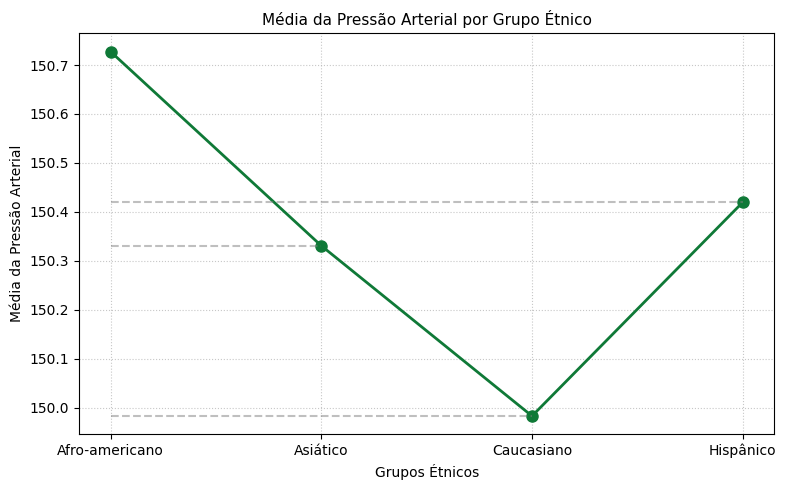

In [ ]:
# Separar os dados por grupo étnico e calcular a média de cada grupo
media_etinia = df_pacientes.groupby('Nome_Etnia')['Pressao_Arterial'].mean()

# Exibir a média de pressão arterial para cada grupo étnico
print("Pressão arterial média por grupo étnico")
for etnia, media in media_etinia.items():
    print(f"{etnia}: {media:.2f} mmHg")

# Realizar a ANOVA
teste_anova, p_value = stats.f_oneway(
    df_pacientes[df_pacientes['Etnia'] == 0]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 1]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 2]['Pressao_Arterial'],
    df_pacientes[df_pacientes['Etnia'] == 3]['Pressao_Arterial']
)

print("-" * 20)
print('F-statistic:', teste_anova)
print('p-value:', p_value)

alpha = 0.05

# Comparando p-valor com alpha
if p_value < alpha:
    resultado_etnia = print("Rejeitamos a hipótese nula. A pressão arterial média não é a mesma em todos os grupos étnicos.")
else:
  resultado_etnia = print("Não rejeitamos a hipótese nula. A pressão arterial média é a mesma em todos os grupos étnicos.")


nomes_etnias = list(media_etinia.keys())
medias_pressao_arterial = list(media_etinia.values) #Removed parentheses from .values

# Plotar o gráfico
plt.figure(figsize=(8, 5))
plt.plot(nomes_etnias, medias_pressao_arterial, color='#0f7937', marker='o', markersize=8, linestyle='-', linewidth=2)

for nome_etnia, media in zip(nomes_etnias, medias_pressao_arterial):
  plt.hlines(media, xmin=0, xmax=nome_etnia, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Grupos Étnicos')
plt.ylabel('Média da Pressão Arterial')
plt.title('Média da Pressão Arterial por Grupo Étnico', fontsize=11)
plt.grid(linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## Questão 07

7. Lúcia é uma pesquisadora e tem o objetivo de entender a relação de gênero neste grupo de pacientes. Acredita-se que há uma relação entre o sexo e condições de saúde adicionais. (Teste qui-quadrado)

In [ ]:
# Separa os dados do dataframe pelas colunas Genero e Estado_Saude
df_genero = df_pacientes['Genero']
df_estado_saude = df_pacientes['Estado_Saude']

# Tabela de contingência
tabela_contingencia = pd.crosstab(df_genero, df_estado_saude)

# Aplica teste qui-quadrado
chi2, p_valor, _, _ = stats.chi2_contingency(tabela_contingencia)

# Nível de significância (alpha)
alpha = 0.05

# Compara o p-valor com alpha
if p_valor < alpha:
  conclusao = ("Rejeitamos a hipótese nula.\n" +
	             "Podemos concluir que existe uma relação significativa entre o gênero e as condições de saúde desta população.\n")
else:
  conclusao = ("Não rejeitamos a hipótese nula.\n" +
	             "Não há evidências suficientes para concluir que existe uma relação significativa entre o gênero e as condições de saúde desta população.\n")

# Resultados
print(f"Conclusão: {conclusao}\np-valor: {round(p_valor, 2)}\nQui-quadrado: {chi2}")

Conclusão: Não rejeitamos a hipótese nula.
Não há evidências suficientes para concluir que existe uma relação significativa entre o gênero e as condições de saúde desta população.

p-valor: 1.0
Qui-quadrado: 0.0


## Questão 08

8. Qual é o intervalo de confiança para a média da pressão arterial entre os pacientes com condições de saúde adicionais? (nível de confiança 95%)

In [ ]:
# Seleciona amostra do Dataframe - Filtra pela coluna Estado_Saude
amostra_condicao_1 = df_pacientes[df_pacientes['Estado_Saude'] == 1]

# Calcula a média e o desvio padrão da pressão arterial
media_pressao_condicoes = amostra_condicao_1['Pressao_Arterial'].mean()
desvio_padrao_condicoes = amostra_condicao_1['Pressao_Arterial'].std()

# Calcula o tamanho da amostra
tamanho_amostra = amostra_condicao_1.shape[0]

# Nível de confiança (95%)
confianca = 0.95

# Nível de significância (alpha)
alpha = 0.05

# Encontra o valor de Z para o nível de confiança
Z = stats.norm.ppf((1 + confianca) / 2)

# Calcula o intervalo de confiança
intervalo_confiancaA = Z * (desvio_padrao_condicoes / (tamanho_amostra ** alpha))
intervalo_confianca = Z * (desvio_padrao_condicoes / np.sqrt(tamanho_amostra))

# Calcula os limites inferior e superior do intervalo de confiança
limite_inferior = media_pressao_condicoes - intervalo_confianca
limite_superior = media_pressao_condicoes + intervalo_confianca

# Resultados
print(f"Intervalo de Confiança: {round(intervalo_confianca, 2)}")
print(f"Limite Inferior: {round(limite_inferior, 2)}")
print(f"Limite Superior: {round(limite_superior, 2)}")

Intervalo de Confiança: 0.9
Limite Inferior: 149.22
Limite Superior: 151.02


## Questão 09


9. A distribuição da pressão arterial na população segue uma distribuição normal?


A. Hipótese Nula (H0): A distribuição da pressão arterial na população segue uma distribuição normal.

B. Hipótese Alternativa (H1): A distribuição da pressão arterial na população não segue uma distribuição normal.

In [ ]:
# Aplicando teste KS
teste_ks, p_valor = stats.kstest(df_pacientes['Pressao_Arterial'], 'norm')

# Nível de significância
alpha = 0.05

# Compara o p-valor com alpha
if p_valor < alpha:
  conclusao = ("Rejeitamos a hipótese nula.\n" +
	             "Podemos concluir que a distribuição da pressão arterial na população segue uma distribuição normal.\n")
else:
  conclusao = ("Não rejeitamos a hipótese nula.\n" +
	             "Não há evidências suficientes para concluir que a distribuição da pressão arterial na população NÃO segue uma distribuição normal.\n")

# Resultados
print(f"Conclusão: {conclusao}\np-valor: {p_valor}")

Conclusão: Rejeitamos a hipótese nula.
Podemos concluir que a distribuição da pressão arterial na população segue uma distribuição normal.

p-valor: 0.0


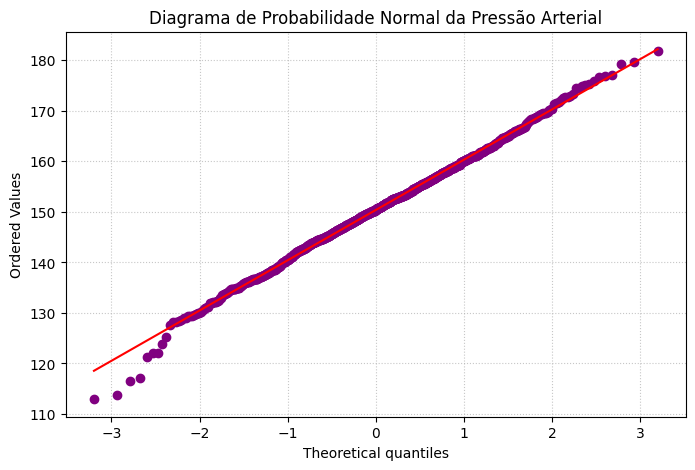

In [ ]:

# Plotar o gráfico
plt.figure(figsize=(8, 5))
stats.probplot(df_pacientes['Pressao_Arterial'], dist="norm", plot=plt)
plt.title('Diagrama de Probabilidade Normal da Pressão Arterial')
plt.grid(linestyle=':', alpha=0.7)
plt.gca().get_lines()[0].set_color('purple')
plt.show()

A distribuição apresenta uma ligeira assimetria negativa, mas mantém uma forma aproximadamente normal, com a maioria dos dados agrupados em torno da média, representada pela linha vermelha